## 5.1.3 Model 3: XGBoost Regressor

Gradient-boosted trees on the unscaled feature set — tree-based models don't need feature scaling. Target is `price`, already log-transformed upstream (Section 3.6), so all metrics below are computed on the log scale unless explicitly converted back to Ringgit (RM) with `np.exp`.

In [1]:
# 5.1.3 Model 3: XGBoost Regressor
# Trained on X_train.csv (unscaled) since tree-based models don't need feature scaling.

import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
import json
from sklearn.model_selection import GridSearchCV
import sys, os

sys.path.append(os.path.dirname(os.path.abspath('__file__')))
from model_utils import evaluate_model, cross_validate_model

MODELLING_DIR = os.path.join("..", "data", "modelling")
MODEL_DIR = os.path.join("..", "models")
os.makedirs(MODEL_DIR, exist_ok=True)

X_train = pd.read_csv(os.path.join(MODELLING_DIR, "X_train.csv"))
X_test = pd.read_csv(os.path.join(MODELLING_DIR, "X_test.csv"))

# price is already log-transformed in the CSV (see Section 3.6) — read as-is
y_train = pd.read_csv(os.path.join(MODELLING_DIR, "y_train.csv"))["price"]
y_test = pd.read_csv(os.path.join(MODELLING_DIR, "y_test.csv"))["price"]

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (3004, 51) | X_test: (751, 51)


In [2]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import KFold

def rm_scale_rmse(y_true_log, y_pred_log):
    y_true_rm = np.exp(y_true_log)
    y_pred_rm = np.exp(y_pred_log)
    return np.sqrt(np.mean((y_true_rm - y_pred_rm) ** 2))

rm_rmse_scorer = make_scorer(rm_scale_rmse, greater_is_better=False)
cv_splitter = KFold(n_splits=5, shuffle=True, random_state=42)

### Hyperparameter Tuning

**Baseline grid search (below, for reference)** covered `n_estimators`, `max_depth`, `learning_rate`, `subsample` only. It picked `max_depth=4, n_estimators=400` and scored well in CV (log-RMSE 0.25), but the fitted model showed a large train/test gap (Train R² 0.957 vs Test R² 0.750, 5-fold CV R² 0.711) — a classic overfitting signature for boosted trees: the search space had no regularization knobs, so the model was free to memorize training rows.

**Fixed below:** add `min_child_weight`, `gamma`, `reg_alpha`, `reg_lambda`, and `colsample_bytree` to the search, and switch to `RandomizedSearchCV` since the expanded grid is too large to search exhaustively. Also add early stopping on a held-out validation split so `n_estimators` self-tunes per candidate instead of being swept as a fixed grid value.

In [3]:
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
}

grid_search = GridSearchCV(
    xgb.XGBRegressor(random_state=42, objective="reg:squarederror"),
    param_grid,
    scoring=rm_rmse_scorer,
    cv=cv_splitter,
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print(f"Best CV score (RM-scale RMSE): RM {-grid_search.best_score_:,.0f}")

# save tuning result for reference/reproducibility
with open(os.path.join(MODEL_DIR, "xgboost_best_params.json"), "w") as f:
    json.dump(grid_search.best_params_, f, indent=2)

C:\Users\Low\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
2 fits failed out of a total of 80.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Low\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Low\AppData\Roaming\Python\Python313\site-packages\xgboost\core.py", line 569, in inner_f
    return func(**kwargs)
  File "C:\Users\Low\AppData\Roaming\Python\Python313\site-packages\xgboost\sklearn.py", line 1

Best params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 400, 'subsample': 0.8}
Best CV score (RM-scale RMSE): RM 168,062


In [4]:
# from sklearn.model_selection import RandomizedSearchCV, train_test_split
# from scipy.stats import randint, uniform

# X_fit, X_val, y_fit, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

# param_distributions = {
#     "max_depth": randint(3, 7),
#     "learning_rate": uniform(0.02, 0.13),
#     "subsample": uniform(0.6, 0.4),
#     "colsample_bytree": uniform(0.6, 0.4),
#     "min_child_weight": randint(1, 10),
#     "gamma": uniform(0, 0.5),
#     "reg_alpha": uniform(0, 2.0),
#     "reg_lambda": uniform(0.5, 3.5),
# }

# base_estimator = xgb.XGBRegressor(
#     random_state=42,
#     objective="reg:squarederror",
#     eval_metric="rmse",
#     n_estimators=1000,          # high ceiling; early stopping will cut it short
#     early_stopping_rounds=30,
# )

# random_search = RandomizedSearchCV(
#     base_estimator,
#     param_distributions=param_distributions,
#     n_iter=60,
#     scoring="neg_root_mean_squared_error",
#     cv=5,
#     n_jobs=-1,
#     random_state=42,
#     verbose=1,
# )

# random_search.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)

# print("Best params:", random_search.best_params_)
# print(f"Best CV score (log-scale RMSE): {-random_search.best_score_:.4f}")

# with open(os.path.join(MODEL_DIR, "xgboost_best_params.json"), "w") as f:
#     json.dump(random_search.best_params_, f, indent=2)

#### Expanded search with regularization + early stopping

In [5]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint, uniform

# Held-out split from the training set for early stopping (X_test stays untouched until final eval)
X_fit, X_val, y_fit, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

param_distributions = {
    "n_estimators": randint(300, 900),
    "max_depth": randint(3, 7),
    "learning_rate": uniform(0.02, 0.13),        # ~0.02-0.15
    "subsample": uniform(0.6, 0.4),               # ~0.6-1.0
    "colsample_bytree": uniform(0.6, 0.4),        # ~0.6-1.0
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 0.5),
    "reg_alpha": uniform(0, 2.0),
    "reg_lambda": uniform(0.5, 3.5),               # ~0.5-4.0
}

base_estimator = xgb.XGBRegressor(
    random_state=42,
    objective="reg:squarederror",
    eval_metric="rmse",
    early_stopping_rounds=30,
)

random_search = RandomizedSearchCV(
    base_estimator,
    param_distributions=param_distributions,
    n_iter=60,
    scoring=rm_rmse_scorer,
    cv=cv_splitter,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

# eval_set needed for early stopping — passed via fit_params
random_search.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)

print("Best params:", random_search.best_params_)
print(f"Best CV score (RM-scale RMSE): RM {-random_search.best_score_:,.0f}")

with open(os.path.join(MODEL_DIR, "xgboost_best_params.json"), "w") as f:
    json.dump(random_search.best_params_, f, indent=2)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


Best params: {'colsample_bytree': np.float64(0.9627313766183017), 'gamma': np.float64(0.13606612469231766), 'learning_rate': np.float64(0.10419971567037711), 'max_depth': 3, 'min_child_weight': 4, 'n_estimators': 558, 'reg_alpha': np.float64(0.013904261062381407), 'reg_lambda': np.float64(2.28761555902148), 'subsample': np.float64(0.7669644012595116)}
Best CV score (RM-scale RMSE): RM 159,917


> **Tuning notes / things worth trying next if the gap is still large:**
> - Drop `max_depth` search ceiling to 5 if Test R² doesn't close the gap — shallower trees regularize more directly than L1/L2 alone.
> - If `State_*` / `PropertyType_*` one-hot columns dominate importance (they do, per the feature-importance table below), consider target encoding instead of one-hot — it can reduce the tree's tendency to split on rare state/property-type combinations.
> - Try `n_iter=100+` for `RandomizedSearchCV` if you have compute budget; 60 is a reasonable starting point, not a ceiling.

In [6]:
# Retrain on the full X_train (not just X_fit) using the tuned params found above,
# with early stopping against the same validation split to pick the right n_estimators.
best_params = {k: v for k, v in random_search.best_params_.items()}

model = xgb.XGBRegressor(
    **best_params,
    random_state=42,
    objective="reg:squarederror",
    eval_metric="rmse",
    early_stopping_rounds=30,
)
model.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)
print(f"Model trained. Best iteration: {model.best_iteration}")


Model trained. Best iteration: 161


In [7]:
# Step 1: find the right n_estimators via early stopping (on X_fit/X_val only)
best_params = dict(random_search.best_params_)
best_params.pop("n_estimators", None)   # 加这一行，避免和下面的 n_estimators=1000 冲突

es_model = xgb.XGBRegressor(
    **best_params,
    random_state=42,
    objective="reg:squarederror",
    eval_metric="rmse",
    n_estimators=1000,
    early_stopping_rounds=30,
)
es_model.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)
best_n_estimators = es_model.best_iteration
print(f"Early-stopped iteration: {best_n_estimators}")

# Step 2: refit on the FULL X_train with that fixed n_estimators, no early stopping
final_params = dict(best_params)
final_params["n_estimators"] = best_n_estimators

model = xgb.XGBRegressor(
    **final_params,
    random_state=42,
    objective="reg:squarederror",
)
model.fit(X_train, y_train)
print("Model trained on full X_train.")

Early-stopped iteration: 161


Model trained on full X_train.


In [8]:
# model = xgb.XGBRegressor(**grid_search.best_params_, random_state=42, objective="reg:squarederror")
# model.fit(X_train, y_train)
# print("Model trained.")

### Evaluation Metrics

Same `evaluate_model` helper as the baseline run — compare Train vs Test R² here against the 0.957 / 0.750 baseline gap to check whether regularization actually helped, not just whether CV score improved.

In [9]:
train_metrics = evaluate_model(model, X_train, y_train, label="Train")
print()
test_metrics = evaluate_model(model, X_test, y_test, label="Test")

# save metrics for report reference
with open(os.path.join(MODEL_DIR, "xgboost_metrics.json"), "w") as f:
    json.dump({"train": train_metrics, "test": test_metrics}, f, indent=2)

Train RMSE:  RM 135,519  (38.7% of median price)
Train MAE:   RM 71,015
Train MAPE:  17.5%
Train R2:    0.8291

Test RMSE:  RM 175,439  (48.7% of median price)
Test MAE:   RM 85,848
Test MAPE:  18.6%
Test R2:    0.7204


### 5-Fold Cross-Validation

In [10]:
cv_results = cross_validate_model(
    xgb.XGBRegressor(**final_params, random_state=42, objective="reg:squarederror"),
    X_train, y_train, n_splits=5,
)

5-fold CV (mean +/- std):
  RMSE:  RM 169,213 +/- 26,280  (48.1% of median price)
  MAE:   RM 83,055 +/- 4,687
  MAPE:  20.0% +/- 0.8%
  R2:    0.7278 +/- 0.0460


### Feature Importance

In [11]:
importance_table = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Top 15 features by importance:")
print(importance_table.head(15))

Top 15 features by importance:
Has_Swimming_Pool                 0.313180
Parking Lot                       0.109509
Has_Security                      0.078567
PropertyType_Condominium          0.064971
Has_Gymnasium                     0.056836
Property Size                     0.041253
Property_Age_Missing              0.036811
Total_Units_Missing               0.036323
Bathroom                          0.035224
PropertyType_Flat                 0.032133
PropertyType_Service_Residence    0.027331
State_Penang                      0.022859
State_Selangor                    0.020075
Parking_Lot_Missing               0.013294
Is_Non_Bumi_Lot                   0.007374
dtype: float32


### Save Model

In [12]:
model_path = os.path.join(MODEL_DIR, "xgboost_model.pkl")
joblib.dump(model, model_path)
print(f"Model saved to {model_path}")

Model saved to ..\models\xgboost_model.pkl


### Demo: Reload & Predict on a Sample Row

In [13]:
# Demo: reload the saved model and predict on an existing test row
import joblib
model = joblib.load(os.path.join(MODEL_DIR, "xgboost_model.pkl"))

sample = X_test.iloc[[0]]           # first row of X_test as a stand-in example
preds_log = model.predict(sample)
preds_rm = np.exp(preds_log)

print(f"Predicted price: RM {preds_rm[0]:,.0f}")
print(f"Actual price:    RM {np.exp(y_test.iloc[0]):,.0f}")

Predicted price: RM 366,229
Actual price:    RM 390,000


### Residual Analysis

Plots residuals (actual − predicted, in RM) on the test set to see where the model struggles most — e.g. underpricing high-end listings, or systematic bias in one price band.

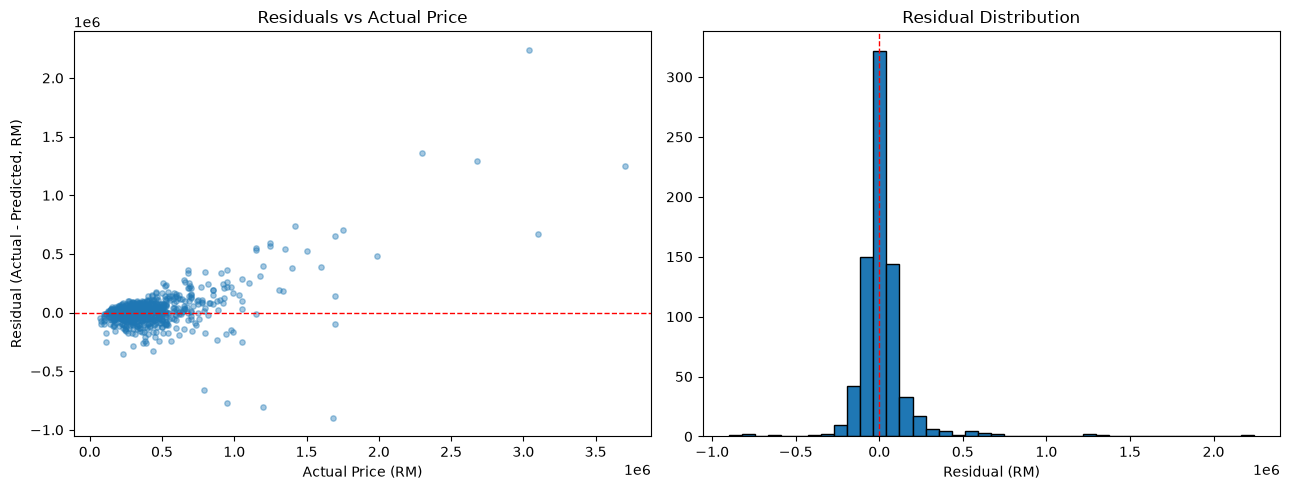

Mean residual (bias): RM 20,446
Residual std:         RM 174,359


,actual_rm,predicted_rm,abs_error_rm
685,3039000.0,798321.125,2240678.875
727,2300000.0,941998.750,1358001.250
350,2680000.0,1390305.250,1289694.750
150,3701000.0,2447349.000,1253651.000
438,1680000.0,2579810.750,899810.750
56,1200000.0,2007880.750,807880.750
454,950000.0,1718288.250,768288.250
108,1420000.0,679927.750,740072.250
139,1750000.0,1048391.000,701609.000
675,3100000.0,2432886.250,667113.750


In [14]:
import matplotlib.pyplot as plt

test_preds_log = model.predict(X_test)
test_preds_rm = np.exp(test_preds_log)
test_actual_rm = np.exp(y_test)
residuals_rm = test_actual_rm - test_preds_rm

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residuals vs actual price — spot whether errors grow with price
axes[0].scatter(test_actual_rm, residuals_rm, alpha=0.4, s=15)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Actual Price (RM)")
axes[0].set_ylabel("Residual (Actual - Predicted, RM)")
axes[0].set_title("Residuals vs Actual Price")

# Distribution of residuals — spot skew / bias
axes[1].hist(residuals_rm, bins=40, edgecolor="black")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Residual (RM)")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

print(f"Mean residual (bias): RM {residuals_rm.mean():,.0f}")
print(f"Residual std:         RM {residuals_rm.std():,.0f}")

# Worst 10 predictions by absolute error — useful to eyeball for data issues / outlier listings
worst = pd.DataFrame({
    "actual_rm": test_actual_rm.values,
    "predicted_rm": test_preds_rm,
    "abs_error_rm": residuals_rm.abs().values,
}).sort_values("abs_error_rm", ascending=False).head(10)
worst

### Sanity Check: Log-Price Transform

In [15]:
print("y_test head (log-price):", y_test.head())
print("y_test dtype:", y_test.dtype)
print("Expected actual price (RM):", np.exp(y_test.iloc[0]))

y_test head (log-price): 0    12.873902
1    12.100712
2    12.089539
3    12.793859
4    12.206073
Name: price, dtype: float64
y_test dtype: float64
Expected actual price (RM): 389999.99999999924


## XGBoost Model - 6 Extra Analysis Cells

These 6 cells add visual diagnostics on top of the existing XGBoost model (`model`, `X_train`, `X_test`, `y_train`, `y_test`, `train_metrics`, `test_metrics`, `importance_table`, `best_params` must already exist from earlier cells in the notebook).

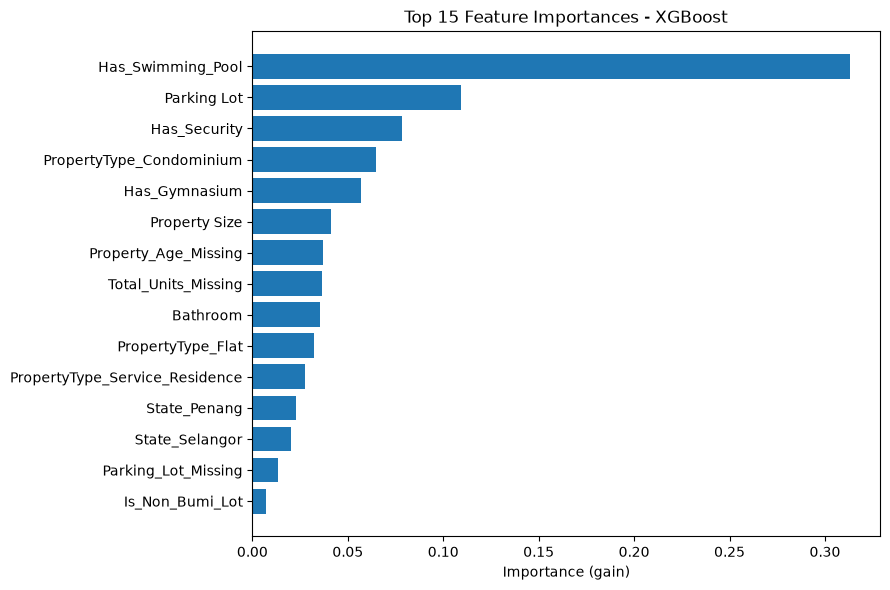

In [16]:
# Which features matter most to the model's predictions
import matplotlib.pyplot as plt

top15 = importance_table.head(15)
plt.figure(figsize=(9, 6))
plt.barh(top15.index[::-1], top15.values[::-1])
plt.xlabel("Importance (gain)")
plt.title("Top 15 Feature Importances - XGBoost")
plt.tight_layout()
plt.show()

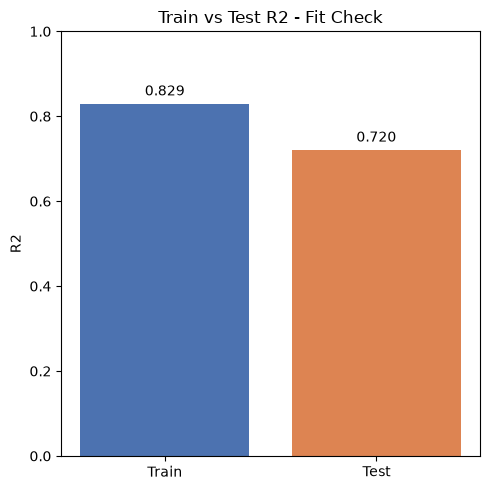

In [17]:
# CELL 2: Train vs Test R2
# Plain explanation: R2 closer to 1 means better predictions. If Train is
# much higher than Test, the model memorized the training data instead of
# learning general patterns (overfitting).
plt.figure(figsize=(5, 5))
plt.bar(["Train", "Test"], [train_metrics["R2"], test_metrics["R2"]], color=["#4C72B0", "#DD8452"])
plt.ylim(0, 1)
plt.ylabel("R2")
plt.title("Train vs Test R2 - Fit Check")
for i, v in enumerate([train_metrics["R2"], test_metrics["R2"]]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

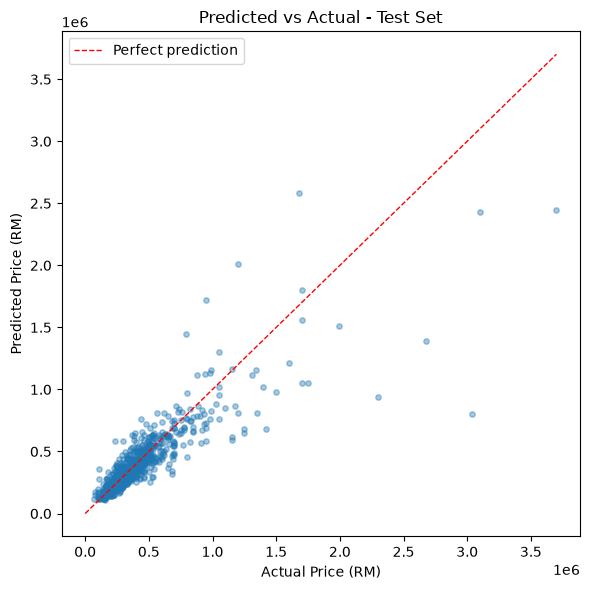

In [18]:
# CELL 3: Predicted vs Actual (Test set)
# Plain explanation: every dot is one house. Dots close to the red line mean
# the prediction matched the real price well. Dots far from the line are the
# model's biggest mistakes.
plt.figure(figsize=(6, 6))
plt.scatter(test_actual_rm, test_preds_rm, alpha=0.4, s=15)
lims = [0, max(test_actual_rm.max(), test_preds_rm.max())]
plt.plot(lims, lims, "r--", linewidth=1, label="Perfect prediction")
plt.xlabel("Actual Price (RM)")
plt.ylabel("Predicted Price (RM)")
plt.title("Predicted vs Actual - Test Set")
plt.legend()
plt.tight_layout()
plt.show()


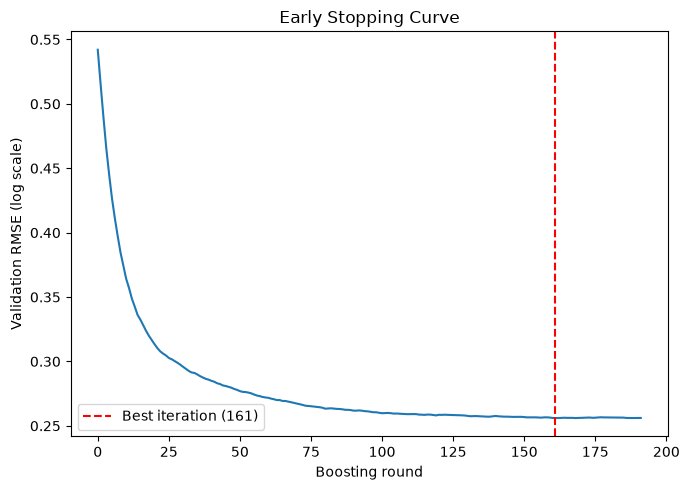

In [19]:
# CELL 4: Early Stopping Curve
# Plain explanation: each round adds one more tree. Error drops at first,
# then flattens or rises. The red dashed line marks where training stopped,
# because adding more trees was no longer helping.
results = es_model.evals_result()
plt.figure(figsize=(7, 5))
plt.plot(results["validation_0"]["rmse"])
plt.axvline(es_model.best_iteration, color="red", linestyle="--", label=f"Best iteration ({es_model.best_iteration})")
plt.xlabel("Boosting round")
plt.ylabel("Validation RMSE (log scale)")
plt.title("Early Stopping Curve")
plt.legend()
plt.tight_layout()
plt.show()


5-fold CV (mean +/- std):
  RMSE:  RM 178,277 +/- 29,755  (50.7% of median price)
  MAE:   RM 86,789 +/- 5,345
  MAPE:  20.7% +/- 1.0%
  R2:    0.6978 +/- 0.0559


5-fold CV (mean +/- std):
  RMSE:  RM 169,213 +/- 26,280  (48.1% of median price)
  MAE:   RM 83,055 +/- 4,687
  MAPE:  20.0% +/- 0.8%
  R2:    0.7278 +/- 0.0460


5-fold CV (mean +/- std):
  RMSE:  RM 167,698 +/- 28,692  (47.7% of median price)
  MAE:   RM 81,995 +/- 4,613
  MAPE:  19.8% +/- 1.0%
  R2:    0.7330 +/- 0.0500


5-fold CV (mean +/- std):
  RMSE:  RM 166,024 +/- 29,251  (47.2% of median price)
  MAE:   RM 80,212 +/- 4,843
  MAPE:  19.4% +/- 1.1%
  R2:    0.7392 +/- 0.0477


5-fold CV (mean +/- std):
  RMSE:  RM 169,741 +/- 30,628  (48.3% of median price)
  MAE:   RM 80,932 +/- 4,669
  MAPE:  19.4% +/- 1.0%
  R2:    0.7262 +/- 0.0563


5-fold CV (mean +/- std):
  RMSE:  RM 170,036 +/- 31,724  (48.4% of median price)
  MAE:   RM 80,692 +/- 4,964
  MAPE:  19.4% +/- 1.2%
  R2:    0.7257 +/- 0.0569


5-fold CV (mean +/- std):
  RMSE:  RM 169,689 +/- 28,508  (48.3% of median price)
  MAE:   RM 80,652 +/- 4,640
  MAPE:  19.3% +/- 1.3%
  R2:    0.7269 +/- 0.0491


5-fold CV (mean +/- std):
  RMSE:  RM 171,025 +/- 28,312  (48.6% of median price)
  MAE:   RM 80,754 +/- 4,893
  MAPE:  19.4% +/- 1.3%
  R2:    0.7223 +/- 0.0498


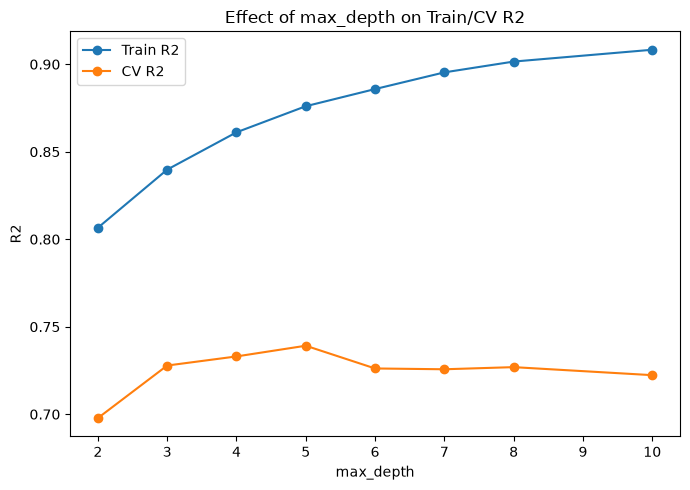

In [20]:
# CELL 5: Effect of max_depth
# Plain explanation: max_depth controls how complex each tree can get.
# Deeper trees keep improving Train R2, but CV R2 eventually flattens or
# drops - that is the point where the model starts overfitting.
depths = [2, 3, 4, 5, 6, 7, 8, 10]
train_r2_list, cv_r2_list = [], []

for d in depths:
    params = dict(best_params)
    params["max_depth"] = d
    params.pop("n_estimators", None)
    temp_model = xgb.XGBRegressor(**params, n_estimators=final_params["n_estimators"], random_state=42, objective="reg:squarederror")
    temp_model.fit(X_train, y_train)
    train_r2_list.append(temp_model.score(X_train, y_train))
    cv = cross_validate_model(
        xgb.XGBRegressor(**params, n_estimators=final_params["n_estimators"], random_state=42, objective="reg:squarederror"),
        X_train, y_train, n_splits=5,
    )
    cv_r2_list.append(cv["mean"]["R2"])

plt.figure(figsize=(7, 5))
plt.plot(depths, train_r2_list, marker="o", label="Train R2")
plt.plot(depths, cv_r2_list, marker="o", label="CV R2")
plt.xlabel("max_depth")
plt.ylabel("R2")
plt.title("Effect of max_depth on Train/CV R2")
plt.legend()
plt.tight_layout()
plt.show()


5-fold CV (mean +/- std):
  RMSE:  RM 235,157 +/- 40,287  (66.9% of median price)
  MAE:   RM 106,807 +/- 7,856
  MAPE:  25.6% +/- 1.2%
  R2:    0.4831 +/- 0.0595


5-fold CV (mean +/- std):
  RMSE:  RM 186,198 +/- 34,008  (52.9% of median price)
  MAE:   RM 89,276 +/- 6,238
  MAPE:  21.4% +/- 1.1%
  R2:    0.6743 +/- 0.0543


5-fold CV (mean +/- std):
  RMSE:  RM 174,927 +/- 27,832  (49.7% of median price)
  MAE:   RM 85,939 +/- 5,200
  MAPE:  20.7% +/- 1.0%
  R2:    0.7107 +/- 0.0432


5-fold CV (mean +/- std):
  RMSE:  RM 169,192 +/- 26,511  (48.1% of median price)
  MAE:   RM 83,231 +/- 4,588
  MAPE:  20.1% +/- 0.8%
  R2:    0.7283 +/- 0.0444


5-fold CV (mean +/- std):
  RMSE:  RM 172,444 +/- 29,955  (49.0% of median price)
  MAE:   RM 83,071 +/- 4,099
  MAPE:  20.0% +/- 0.8%
  R2:    0.7173 +/- 0.0554


5-fold CV (mean +/- std):
  RMSE:  RM 169,945 +/- 26,436  (48.3% of median price)
  MAE:   RM 83,162 +/- 4,263
  MAPE:  20.1% +/- 0.8%
  R2:    0.7252 +/- 0.0493


5-fold CV (mean +/- std):
  RMSE:  RM 179,025 +/- 19,521  (50.9% of median price)
  MAE:   RM 85,155 +/- 4,492
  MAPE:  20.4% +/- 1.0%
  R2:    0.6916 +/- 0.0540


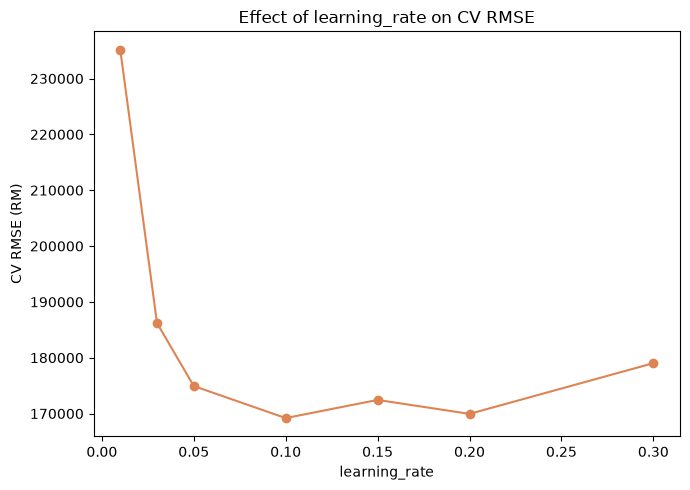

In [21]:
# CELL 6: Effect of learning_rate
# Plain explanation: learning_rate controls how fast each tree learns. Too
# slow and the model may not learn enough in time; too fast and it can
# overshoot and make worse guesses. The lowest point on this curve is the
# best rate for this data.
rates = [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.3]
cv_rmse_list = []

for lr in rates:
    params = dict(best_params)
    params["learning_rate"] = lr
    params.pop("n_estimators", None)
    temp_model = xgb.XGBRegressor(**params, n_estimators=final_params["n_estimators"], random_state=42, objective="reg:squarederror")
    cv = cross_validate_model(temp_model, X_train, y_train, n_splits=5)
    cv_rmse_list.append(cv["mean"]["RMSE"])

plt.figure(figsize=(7, 5))
plt.plot(rates, cv_rmse_list, marker="o", color="#DD8452")
plt.xlabel("learning_rate")
plt.ylabel("CV RMSE (RM)")
plt.title("Effect of learning_rate on CV RMSE")
plt.tight_layout()
plt.show()


### Environment / Package Versions

For reproducibility — pin these in `requirements.txt` if not already.

In [22]:
import pandas; pandas.__version__

'3.0.3'

In [23]:
import numpy; numpy.__version__

'2.5.1'

In [24]:
import matplotlib; matplotlib.__version__

'3.11.1'

In [25]:
import seaborn; seaborn.__version__

'0.13.2'

In [26]:
import joblib; joblib.__version__

'1.5.3'

In [27]:
import streamlit; streamlit.__version__

'1.59.2'